In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# Load clean data
df = pd.read_csv("spark_spread_project/data/clean/merged_hourly.csv")
df["price_timestamp"] = pd.to_datetime(df["price_timestamp"])

print(f"Rows    : {len(df):,}")
print(f"Columns : {list(df.columns)}")
print(f"From    : {df['price_timestamp'].min()}")
print(f"To      : {df['price_timestamp'].max()}")

Rows    : 26,280
Columns : ['price_timestamp', 'power_eur_mwh', 'gas_eur_mwh', 'carbon_eur_tonne']
From    : 2021-01-01 00:00:00
To      : 2023-12-31 23:00:00


In [2]:
# ── Spark Spread Parameters ───────────────────────────────────────
ETA               = 0.50    # plant efficiency (50%)
CARBON_INTENSITY  = 0.35    # tonnes CO2 per MWh of gas burned

# ── Calculate Spark Spread ────────────────────────────────────────
df["spark_spread"] = (
    df["power_eur_mwh"]
    - (df["gas_eur_mwh"] / ETA)
    - (CARBON_INTENSITY * df["carbon_eur_tonne"])
)

print("Spark spread calculated.")
print(f"\nSpread range:")
print(f"  Min  : {df['spark_spread'].min():.2f} EUR/MWh")
print(f"  Max  : {df['spark_spread'].max():.2f} EUR/MWh")
print(f"  Mean : {df['spark_spread'].mean():.2f} EUR/MWh")
print(f"\nFirst 3 rows:")
print(df[["price_timestamp","power_eur_mwh","gas_eur_mwh","carbon_eur_tonne","spark_spread"]].head(3))

Spark spread calculated.

Spread range:
  Min  : -670.61 EUR/MWh
  Max  : 475.46 EUR/MWh
  Mean : -29.65 EUR/MWh

First 3 rows:
      price_timestamp  power_eur_mwh  gas_eur_mwh  carbon_eur_tonne  \
0 2021-01-01 00:00:00          49.57       19.845             33.89   
1 2021-01-01 01:00:00          43.51       19.845             33.89   
2 2021-01-01 02:00:00          40.83       19.845             33.89   

   spark_spread  
0       -1.9815  
1       -8.0415  
2      -10.7215  


In [3]:
# ── Regime Labels ─────────────────────────────────────────────────
conditions = [
    (df["price_timestamp"] < "2021-09-01"),
    (df["price_timestamp"] >= "2021-09-01") & (df["price_timestamp"] < "2023-01-01"),
    (df["price_timestamp"] >= "2023-01-01")
]
labels = ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]

df["regime"] = np.select(conditions, labels, default="C - Recovery")

print("Regime distribution:")
print(df["regime"].value_counts().sort_index())
print(f"\nSpread mean by regime:")
for label in labels:
    mean = df[df["regime"] == label]["spark_spread"].mean()
    print(f"  {label:20s} : {mean:.2f} EUR/MWh")

Regime distribution:
regime
A - Pre-Crisis     5832
B - Crisis        11688
C - Recovery       8760
Name: count, dtype: int64

Spread mean by regime:
  A - Pre-Crisis       : -7.23 EUR/MWh
  B - Crisis           : -50.04 EUR/MWh
  C - Recovery         : -17.37 EUR/MWh


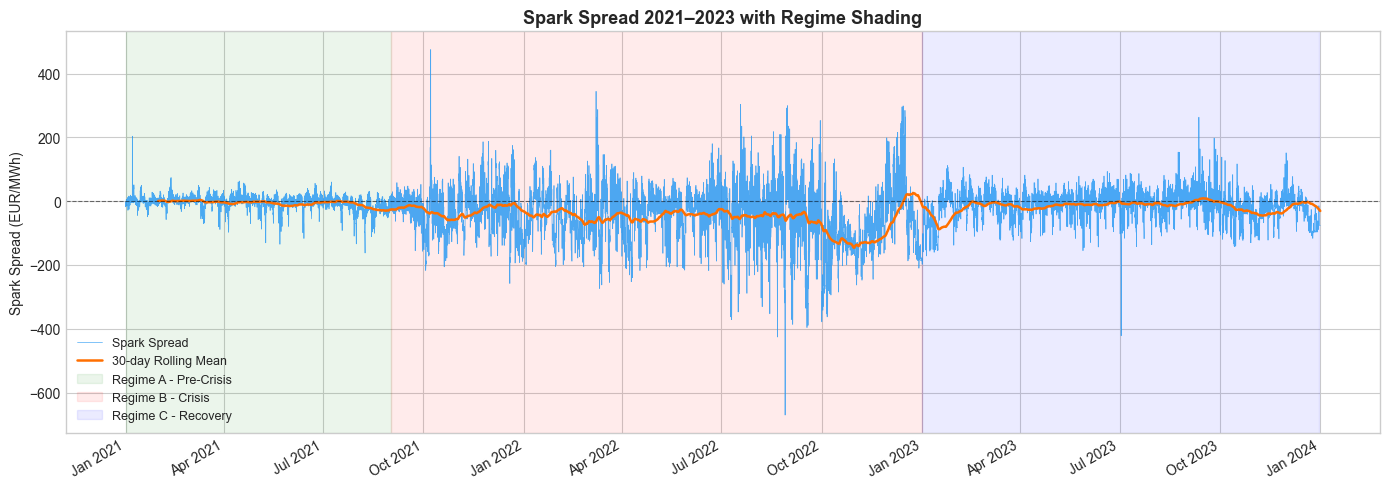

Chart saved.


In [4]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 5))

# Plot spark spread
ax.plot(df["price_timestamp"], df["spark_spread"],
        color="#2196F3", linewidth=0.5, alpha=0.8, label="Spark Spread")

# Rolling 30-day mean
rolling_mean = df["spark_spread"].rolling(window=720).mean()
ax.plot(df["price_timestamp"], rolling_mean,
        color="#FF6F00", linewidth=1.8, label="30-day Rolling Mean")

# Shade regimes
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-09-01"),
           alpha=0.08, color="green", label="Regime A - Pre-Crisis")
ax.axvspan(pd.Timestamp("2021-09-01"), pd.Timestamp("2023-01-01"),
           alpha=0.08, color="red", label="Regime B - Crisis")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"),
           alpha=0.08, color="blue", label="Regime C - Recovery")

# Zero line
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("Spark Spread 2021–2023 with Regime Shading", fontsize=13, fontweight="bold")
ax.set_ylabel("Spark Spread (EUR/MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()

plt.savefig("spark_spread_project/data/clean/02_spark_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [5]:
import subprocess
subprocess.run(["pip", "install", "statsmodels"], check=True)

CompletedProcess(args=['pip', 'install', 'statsmodels'], returncode=0)

In [6]:
from statsmodels.tsa.stattools import adfuller

print("Augmented Dickey-Fuller Test — Mean Reversion by Regime")
print("=" * 55)
print("H0: Series has a unit root (NOT mean-reverting)")
print("If p < 0.05 → reject H0 → series IS mean-reverting\n")

for label in ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]:
    subset = df[df["regime"] == label]["spark_spread"].dropna()
    result = adfuller(subset)
    conclusion = "MEAN-REVERTING ✓" if result[1] < 0.05 else "NOT mean-reverting ✗"
    print(f"Regime {label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Conclusion    : {conclusion}")
    print()

Augmented Dickey-Fuller Test — Mean Reversion by Regime
H0: Series has a unit root (NOT mean-reverting)
If p < 0.05 → reject H0 → series IS mean-reverting

Regime A - Pre-Crisis
  ADF Statistic : -7.5011
  p-value       : 0.000000
  Conclusion    : MEAN-REVERTING ✓

Regime B - Crisis
  ADF Statistic : -10.7317
  p-value       : 0.000000
  Conclusion    : MEAN-REVERTING ✓

Regime C - Recovery
  ADF Statistic : -9.1496
  p-value       : 0.000000
  Conclusion    : MEAN-REVERTING ✓



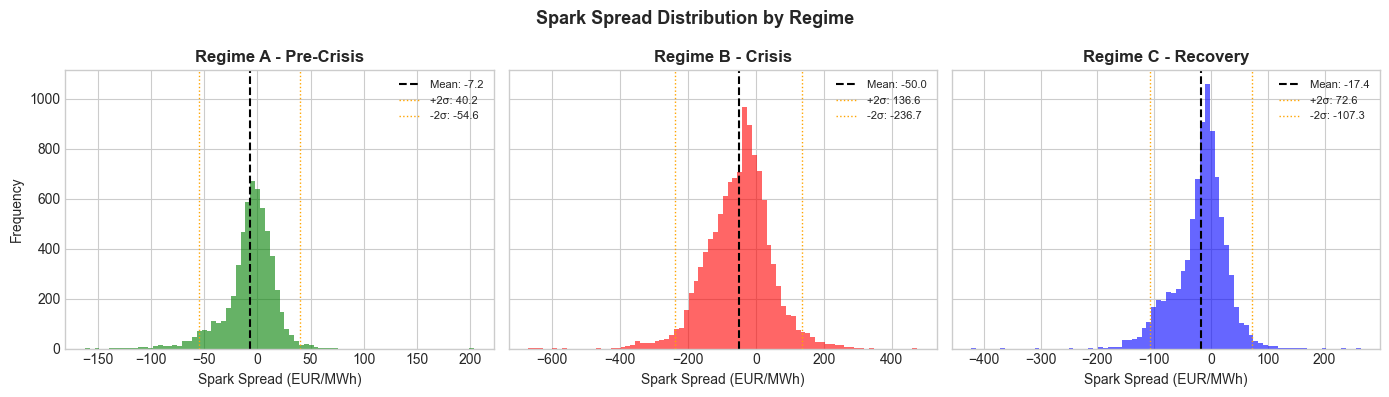

Chart saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

colors = {"A - Pre-Crisis": "green", "B - Crisis": "red", "C - Recovery": "blue"}

for ax, label in zip(axes, ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]):
    subset = df[df["regime"] == label]["spark_spread"]
    mean   = subset.mean()
    std    = subset.std()

    ax.hist(subset, bins=80, color=colors[label], alpha=0.6, edgecolor="none")
    ax.axvline(mean, color="black", linewidth=1.5, linestyle="--", label=f"Mean: {mean:.1f}")
    ax.axvline(mean + 2*std, color="orange", linewidth=1, linestyle=":", label=f"+2σ: {mean+2*std:.1f}")
    ax.axvline(mean - 2*std, color="orange", linewidth=1, linestyle=":", label=f"-2σ: {mean-2*std:.1f}")

    ax.set_title(f"Regime {label}", fontweight="bold")
    ax.set_xlabel("Spark Spread (EUR/MWh)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
fig.suptitle("Spark Spread Distribution by Regime", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("spark_spread_project/data/clean/03_spread_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")